# 1. Importar librerias

In [12]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import *
import sklearn.metrics
import imblearn.metrics
from imblearn.metrics import specificity_score
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pickle

# 2. Cargar el conjunto de datos

In [7]:
path_train = "../data/processed/clean_train.csv"
path_test = "../data/processed/clean_test.csv"

train_data = pd.read_csv(path_train)
test_data = pd.read_csv(path_test)

X_train = train_data.drop(["Outcome"], axis=1)
y_train = train_data["Outcome"]
X_test = test_data.drop(["Outcome"], axis=1)
y_test = test_data["Outcome"]

print(f"Datos listos. Registros de entrenamiento: {len(X_train)}")

Datos listos. Registros de entrenamiento: 586


# 3. Construcción del boosting

Learning Rate: 0.001 -> Accuracy: 0.6395
Learning Rate: 0.01 -> Accuracy: 0.7347
Learning Rate: 0.05 -> Accuracy: 0.7075
Learning Rate: 0.1 -> Accuracy: 0.7143
Learning Rate: 0.2 -> Accuracy: 0.6803


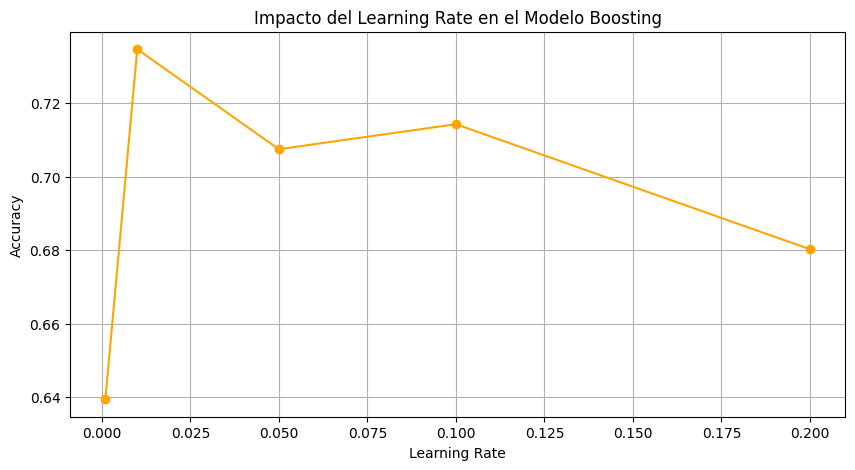

In [9]:
# Se prueba con el hiperparámetro 'learning_rate' (tasa de aprendizaje) 
# y 'n_estimators' (número de iteraciones de corrección)
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.2]
n_estimators = 100
accuracies = []

for lr in learning_rates:
    # El modelo aprende secuencialmente
    model = XGBClassifier(n_estimators=n_estimators, learning_rate=lr, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"Learning Rate: {lr} -> Accuracy: {acc:.4f}")

# Graficar las conclusiones
plt.figure(figsize=(10, 5))
plt.plot(learning_rates, accuracies, marker='o', color='orange')
plt.title('Impacto del Learning Rate en el Modelo Boosting')
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

LR: 0.01 | Estimadores: 50 | Accuracy: 0.7075
LR: 0.01 | Estimadores: 100 | Accuracy: 0.7347
LR: 0.01 | Estimadores: 150 | Accuracy: 0.7211
LR: 0.1 | Estimadores: 50 | Accuracy: 0.6939
LR: 0.1 | Estimadores: 100 | Accuracy: 0.7143
LR: 0.1 | Estimadores: 150 | Accuracy: 0.7075
LR: 0.2 | Estimadores: 50 | Accuracy: 0.7007
LR: 0.2 | Estimadores: 100 | Accuracy: 0.6803
LR: 0.2 | Estimadores: 150 | Accuracy: 0.6871


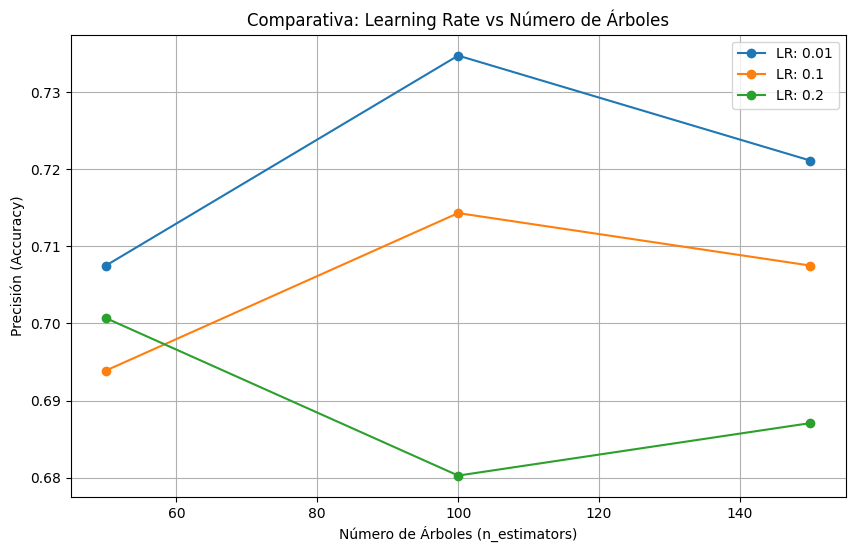

In [10]:
# Probamos combinaciones de ambos
l_rates = [0.01, 0.1, 0.2]
n_estimadores = [50, 100, 150]

plt.figure(figsize=(10, 6))

for lr in l_rates:
    acc_list = []
    for n in n_estimadores:
        model = XGBClassifier(n_estimators=n, learning_rate=lr, random_state=42)
        model.fit(X_train, y_train)
        acc = model.score(X_test, y_test)
        acc_list.append(acc)
        print(f"LR: {lr} | Estimadores: {n} | Accuracy: {acc:.4f}")
    
    plt.plot(n_estimadores, acc_list, label=f'LR: {lr}', marker='o')

plt.title('Comparativa: Learning Rate vs Número de Árboles')
plt.xlabel('Número de Árboles (n_estimators)')
plt.ylabel('Precisión (Accuracy)')
plt.legend()
plt.grid(True)
plt.show()

## Interpretación: 
El análisis de las gráficas de Boosting muestra que el modelo es sensible a la combinación entre la velocidad de aprendizaje y el número de iteraciones. En la primera optimización, el pico de precisión máximo se alcanza con un Learning Rate (LR) de 0.01, lo que indica que el algoritmo requiere correcciones graduales sobre los errores de los árboles anteriores para alcanzar el valor óptimo. Cuando la tasa de aprendizaje supera el 0.05, el rendimiento disminuye, lo que sugiere que incrementos mayores introducen inestabilidad en la predicción.

En la segunda gráfica, la configuración con mayor precisión es LR: 0.01 con 100 árboles. Con un aprendizaje de 0.2, la precisión cae después de los 50 árboles, lo que evidencia que el modelo empieza a memorizar el ruido de los datos (sobreajuste) en lugar de identificar patrones generales. En conclusión, para este conjunto de datos, el Boosting es más efectivo con una tasa de aprendizaje baja y un número moderado de estimadores.

# 4. Guardar el modelo

In [13]:
# Configuración basada en los resultados de las gráficas
modelo_boosting_final = XGBClassifier(n_estimators=100, learning_rate=0.01, random_state=42)
modelo_boosting_final.fit(X_train, y_train)

# Ruta en el Workspace
ruta_save = "/workspaces/steven10015-intro-ml/models/boosting_final.sav"

with open(ruta_save, 'wb') as f:
    pickle.dump(modelo_boosting_final, f)

print(f"Modelo Boosting guardado en: {ruta_save}")

Modelo Boosting guardado en: /workspaces/steven10015-intro-ml/models/boosting_final.sav


# 5. Comparación

El estudio comparativo realizado a través de los tres proyectos (Árbol de Decisión, Random Forest y Boosting) demuestra una progresión clara en la capacidad de generalización del modelo. El Árbol de Decisión inicial estableció una base de referencia con un Accuracy de 0.7143, pero mostró una limitación crítica en su sensibilidad, detectando solo al 51% de los pacientes con diabetes (Recall de 0.51).

La transición a modelos de conjunto (ensemble) permitió mitigar errores de varianza y sesgo detectados originalmente. El Random Forest incrementó la precisión total a 0.7347 mediante la combinación de múltiples árboles con profundidad limitada (max_depth: 5). Por su parte, el modelo Boosting (XGBoost), tras una optimización de hiperparámetros, logró igualar este rendimiento utilizando una configuración de Learning Rate de 0.01 y 100 estimadores.

Veredicto Final: El modelo seleccionado para la implementación es el Boosting. Aunque presenta una precisión global similar al Random Forest, su arquitectura secuencial permite una corrección de errores más precisa en la Clase 1 (Diabetes), que es la variable con menor rendimiento en todos los modelos debido a la complejidad de sus patrones. Se confirma que factores clínicos como la Glucosa y el BMI mantienen la correlación más alta con el diagnóstico en todas las etapas del análisis.